In [1]:
import pandas as  pd 
import matplotlib.pyplot as plt 
import numpy as np
from SFstarred.utils import plot_image_and_noisemap
from SFstarred.save_and_read import read_hdf5_to_dict

In [2]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
data_f160W = pd.read_pickle("data_for_starred/data_for_starred_F160_0214.pickle")

## Overview

This notebook applies the image-deconvolution procedure presented in the `start_here.ipynb` notebook from `starred`.

In [5]:

narrow_psfs = np.load('narrows_psfs/f160_narrow_psfs.npy')

if len(narrow_psfs.shape)==2:
	narrow_psfs = narrow_psfs[None,:]

In [6]:
#"Weight map = 1 / sigma2"

In [9]:
data_f160W.keys()

dict_keys(['data', 'sigma2', 'stars_data', 'stars_sigma2', 'coord_pix_images', 'images_names', 'coord_pix_images_dict', 'selected_star_indices', 'non_selected_stars_index', 'coord_pix_non_images'])

In [68]:
data_f160W["coord_pix_non_images"]

array([[20.10733574, 19.12601003]])

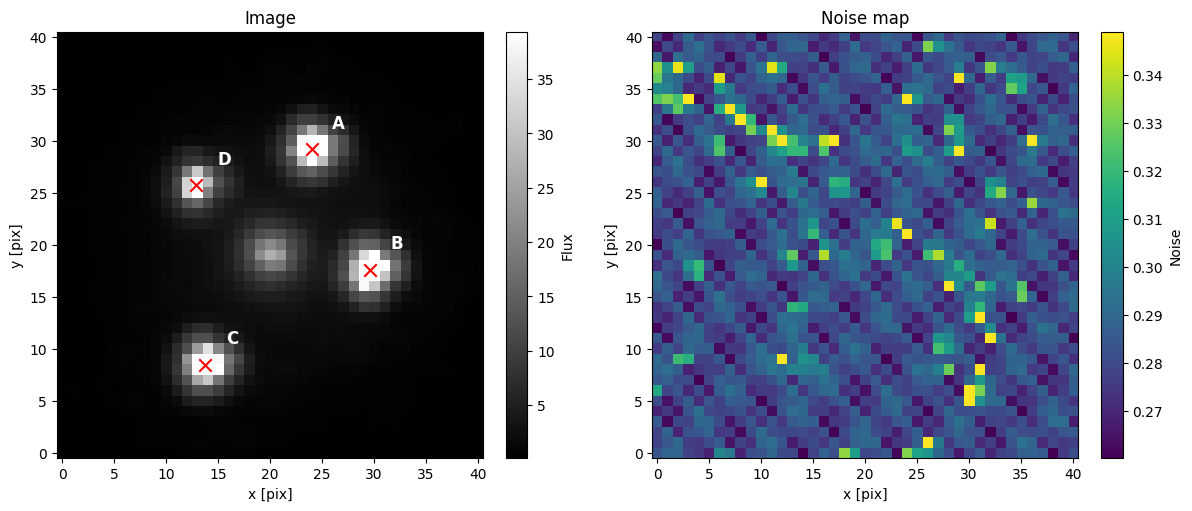

(1, 41, 41) (1, 41, 41)
[ 9.60743656  4.01177314 -6.20281186 -7.0881054 ]
[ -2.39260519   9.18362889 -11.53556347   5.7310841 ]


In [162]:
data = data_f160W["data"]#['data_cutout']
sigma2 = data_f160W['sigma2']
noisemaps = np.sqrt(sigma2)#['sigma2']
image_positions = data_f160W["coord_pix_images"]
image_names = data_f160W["images_names"]
coord_pix_images_dict = data_f160W["coord_pix_images_dict"]
fig, ax = plot_image_and_noisemap(
    data=data[0],
    noisemaps=noisemaps[0],
    image_positions=image_positions,
    image_names=image_names,
    vmin=np.nanpercentile(data, 1),
    vmax=np.nanpercentile(data, 99),
    noise_vmin=np.nanpercentile(noisemaps, 1),
    noise_vmax=np.nanpercentile(noisemaps, 99),
)
plt.show()
im_size = data.shape[1]
offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = image_positions[:,0] - offset

ys = image_positions[:,1] - offset
try:
	coord_pix_non_images = data_f160W["coord_pix_non_images"]
	ptx_non_lens = coord_pix_non_images[:,0] - offset
	pty_non_lens = coord_pix_non_images[:,1] - offset
except:
     print("no extra obj")
# xs = np.array([coord_pix_images_dict[name][0] for name in 'ABCD']) - offset
# ys = np.array([coord_pix_images_dict[name][1] for name in 'ABCD']) - offset

brightnesses = len(data) * 4 * [np.max(data)]
print(data.shape,noisemaps.shape)
np.median(data[0]),np.median(noisemaps[0])
print(xs)
print(ys)

In [163]:
from SFstarred.stars_cut import normalize_data_error
from SFstarred.plots import twoplot
import numpy as np 
norm_factor,data,sigma2,*_, = normalize_data_error(data,1/sigma2,print_=False)#stars
noisemaps = np.sqrt(sigma2)

In [164]:
model, k_init, k_up, k_down, k_fixed = setup_model(data=data, 
                                                   sigma_2=sigma2, 
                                                   s=narrow_psfs, 
                                                   xs=xs,
                                                   ys=ys,
                                                   initial_a=brightnesses,
                                                   subsampling_factor=2)

In [165]:
k_fixed['kwargs_background']['h'] = k_init['kwargs_background']['h']

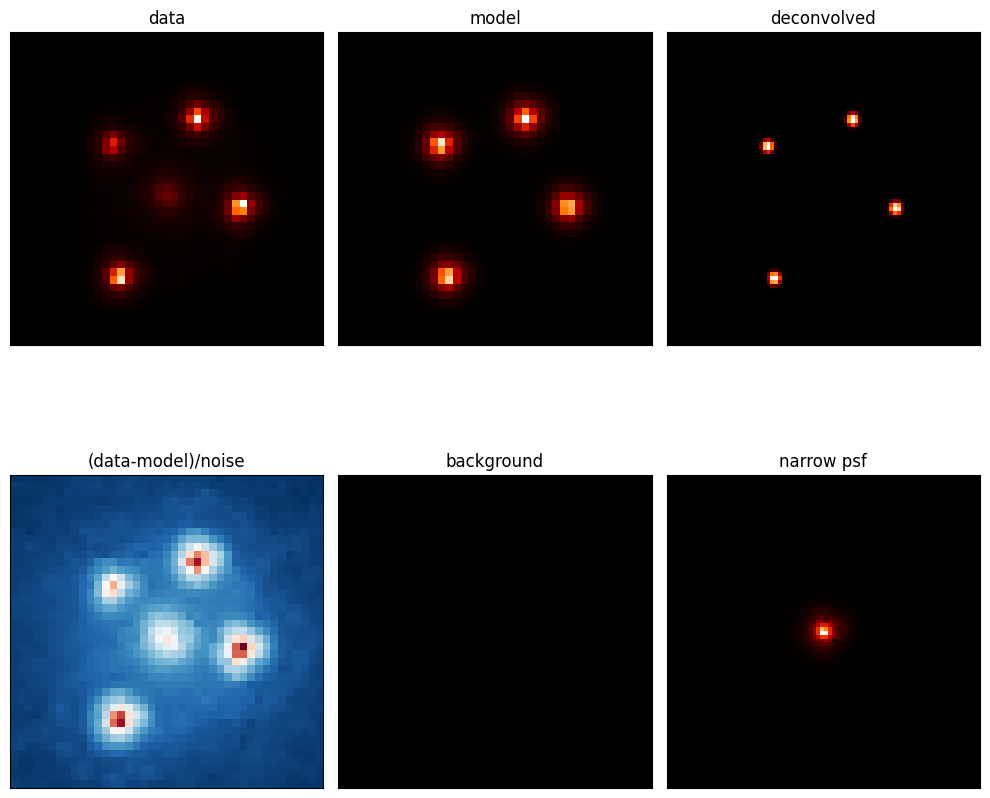

In [166]:
view_deconv_model(model, k_init, data, sigma2, figsize=(10,10))

In [167]:
 # the params needs the initial guess, fixed params and boundaries:
params = ParametersDeconv(k_init, k_fixed, k_up, k_down)
# the loss needs to see our data, noisemaps, model, and the params class:
loss = Loss(data, model, params, noisemaps**2)
# now we can make an optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')

In [168]:
# optimize (this returns some metrics, but we don't need them here.)
optim.minimize(maxiter=70)
# the best fit is automatically given to the params:
k_optim = params.best_fit_values(as_kwargs=True)

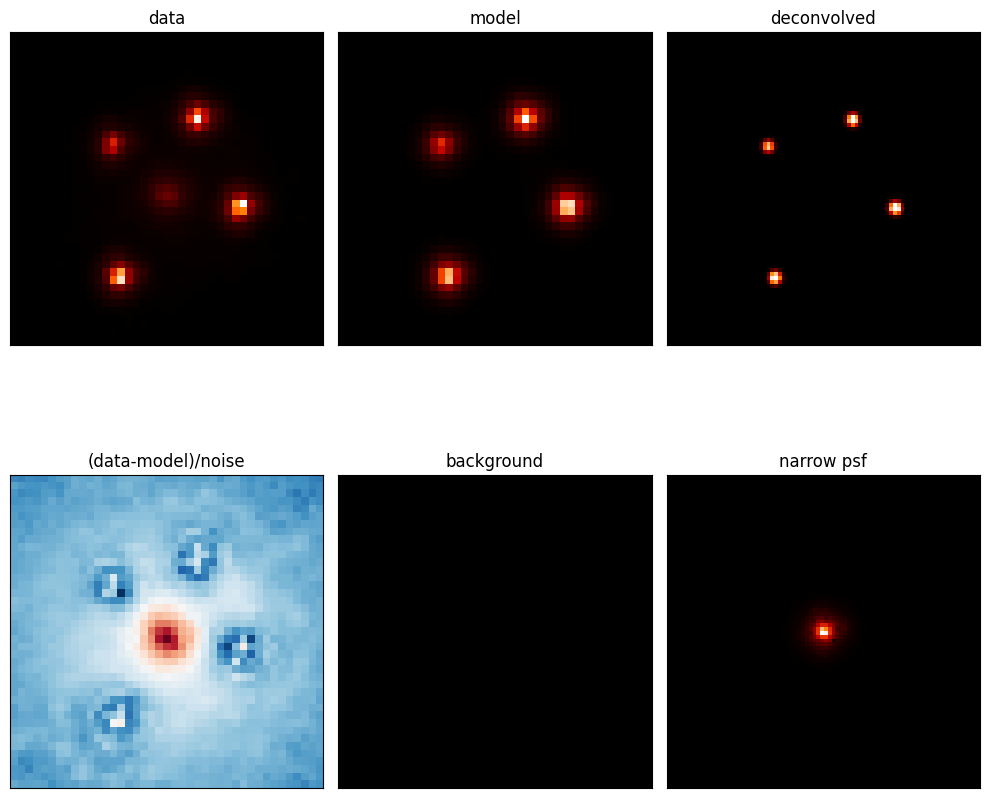

In [169]:
view_deconv_model(model, k_optim, data, sigma2, figsize=(10,10))

In [170]:
 # remove the background fixing:
del k_fixed['kwargs_background']['h']
# calculate the propagation of the noise:
W = propagate_noise(model, noisemaps, k_init, upsampling_factor=2)[0]

In [171]:
# start from our optimized params of before
params = ParametersDeconv(k_optim, k_fixed, k_up, k_down)
# this time we provide the noise scaling to the loss
loss = Loss(data, model, params, noisemaps**2, W=W)
# new optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')
# let's go directly:
optim.minimize(maxiter=30)
k_optim_with_background = params.best_fit_values(as_kwargs=True).copy()

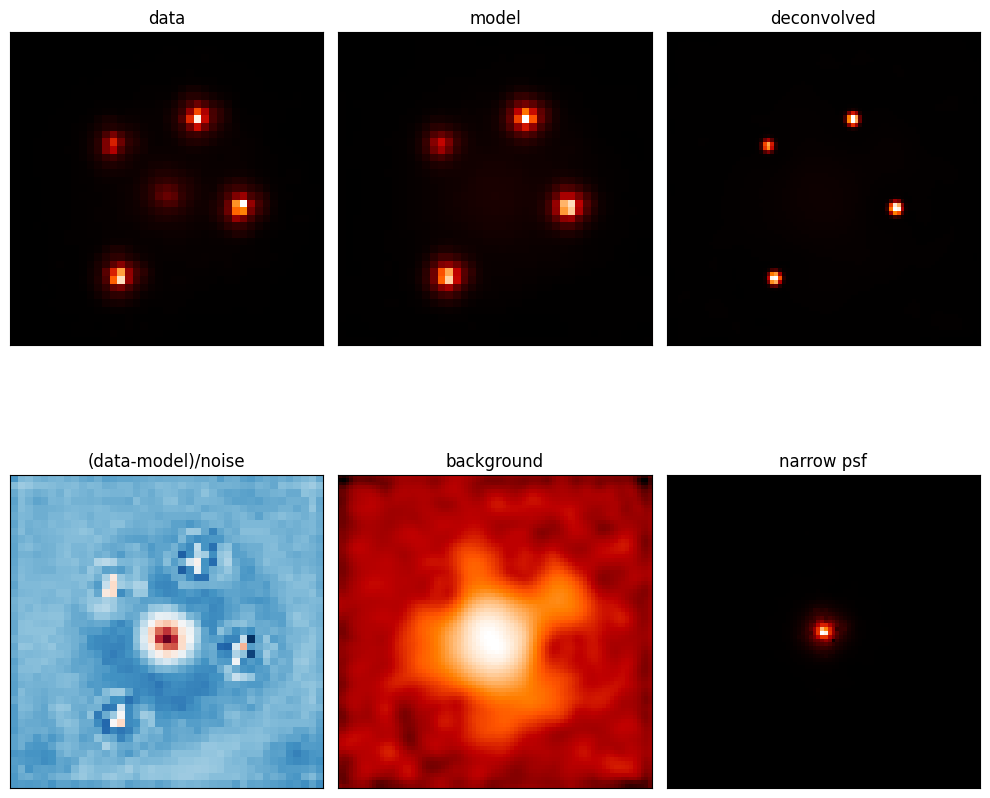

In [172]:
view_deconv_model(model, k_optim_with_background, data, noisemaps**2, figsize=(10,10))

{'kwargs_analytic': {'c_x': array([ 9.60743656,  4.01177314, -6.20281186, -7.0881054 ]), 'c_y': array([ -2.39260519,   9.18362889, -11.53556347,   5.7310841 ]), 'dx': array([0.]), 'dy': array([0.]), 'alpha': array([0.]), 'a': array([200., 200., 200., 200.])}, 'kwargs_background': {'h': array([0., 0., 0., ..., 0., 0., 0.], shape=(6724,)), 'mean': array([0.])}, 'kwargs_sersic': {'amp': [], 'R_sersic': [], 'n_sersic': [], 'center_x': [], 'center_y': [], 'e1': [], 'e2': []}}


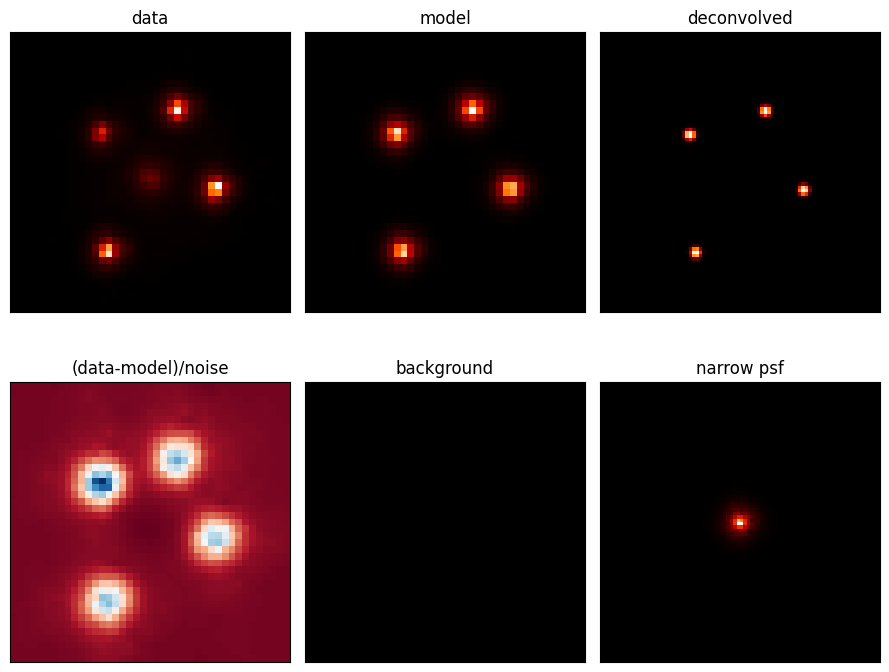

In [173]:
initial_c_x = xs
initial_c_y =ys

brightnesses = len(data) * 4 * [2e4]

model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(data, 
                                                                       noisemaps**2, 
                                                                       narrow_psfs, 
                                                                       initial_c_x,
                                                                       initial_c_y,
                                                                       2,
                                                                       initial_a = brightnesses,
                                                                       N_sersic = 0)


parameters = ParametersDeconv(kwargs_init, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

# print our initial parameters:
print(kwargs_init)
view_deconv_model(model, kwargs_init, data, noisemaps**2)

In [174]:
from copy import deepcopy
from pprint import pprint
from starred.procedures.deconvolution_routines import multi_steps_deconvolution
from starred.plots.plot_function import view_deconv_model, plot_loss, plot_deconvolution

Step 1, fixing : ['pts-source-astrometry', 'background']
Step 1/2 took  5 seconds
Kwargs partial at step 1/2 {'kwargs_analytic': {'a': Array([12.071761, 10.739053, 10.576177,  6.771163], dtype=float32), 'c_x': Array([ 9.607436 ,  4.011773 , -6.2028117, -7.088105 ], dtype=float32), 'c_y': Array([ -2.3926053,   9.183629 , -11.535563 ,   5.731084 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  7877.407
Overall Reduced Chi2 :  9.372287
Step 2, fi

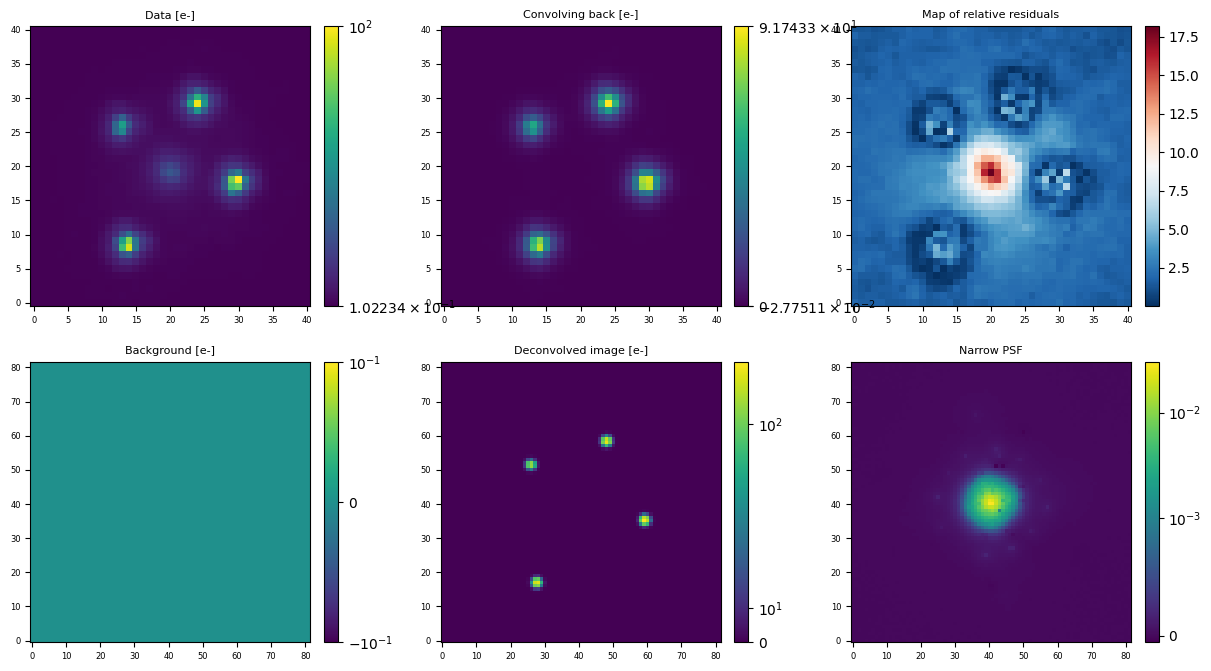

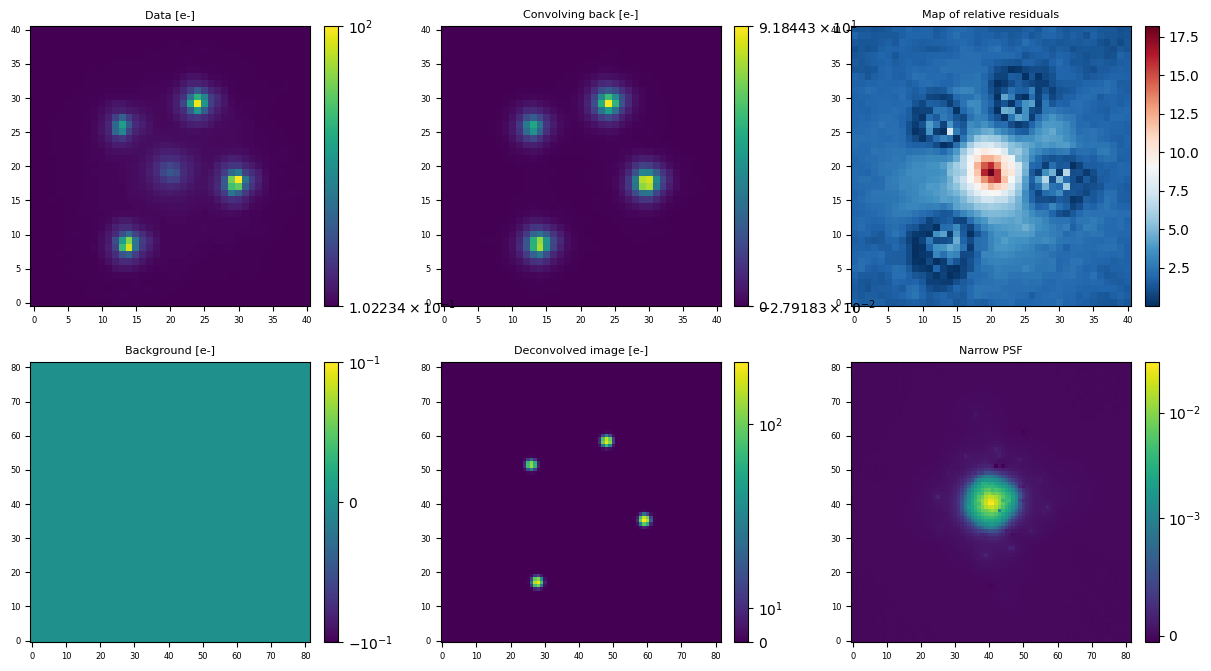

In [175]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [['pts-source-astrometry', 'background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
                    ['background'], #step 2: release astrometry, keep the pixelated background constant.
        ]
    
#Since we have no regularisation, we can use 'l-bfgs-b'. 
optim_list = ['l-bfgs-b','l-bfgs-b']

#l-fgs-b, you can use the following parameters: 
kwargs_lbfgs = {'maxiter':50}

#list of configuration for the optimsers 
kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

#we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
prior_list=[None,None]

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, noisemaps**2, narrow_psfs, 2,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 0, lambda_hf =0, 
                                                                                    lambda_positivity_ps=100, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

{'kwargs_analytic': {'a': Array([12.0781975, 10.74052  , 10.612028 ,  6.7827015], dtype=float32),
                     'alpha': Array([0.], dtype=float32),
                     'c_x': Array([ 9.57797  ,  4.0354633, -6.1393633, -7.035249 ], dtype=float32),
                     'c_y': Array([ -2.3799424,   9.17452  , -11.468943 ,   5.7161036], dtype=float32),
                     'dx': Array([0.], dtype=float32),
                     'dy': Array([0.], dtype=float32)},
 'kwargs_background': {'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
                       'mean': Array([0.], dtype=float32)},
 'kwargs_sersic': {'R_sersic': Array([], shape=(0,), dtype=float32),
                   'amp': Array([], shape=(0,), dtype=float32),
                   'center_x': Array([], shape=(0,), dtype=float32),
                   'center_y': Array([], shape=(0,), dtype=float32),
                   'e1': Array([], shape=(0,), dtype=float32),
                   'e2': Array([], shape=(0,), dtype=f

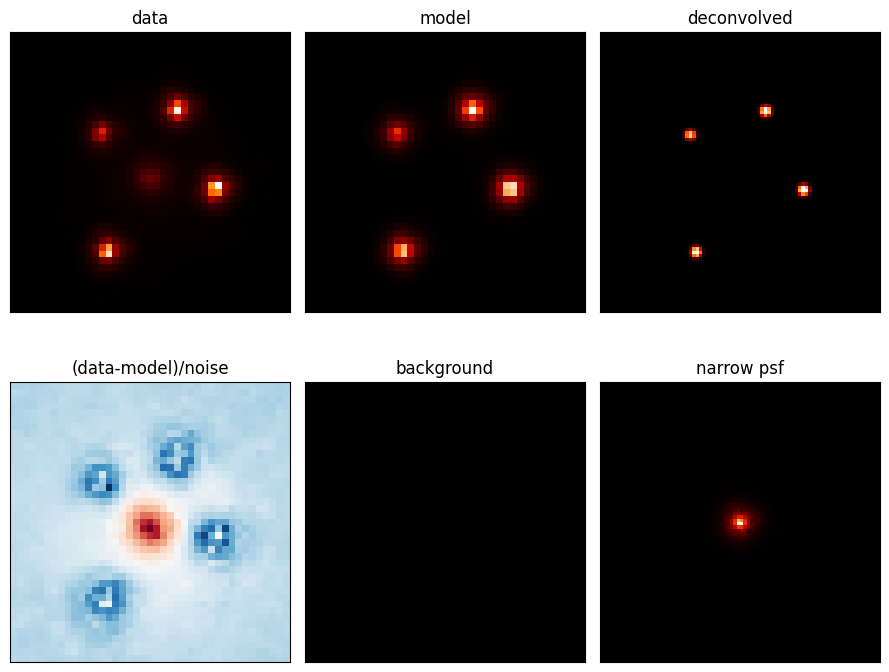

In [176]:
# Printing and visualizing the partial results
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
pprint(kwargs_partial)
view_deconv_model(model, kwargs_partial, data,  noisemaps**2)

Step 1, fixing : []


optax.adabelief: 100%|██████████| 500/500 [00:04<00:00, 123.58it/s]


Step 1/2 took  4 seconds
Kwargs partial at step 1/2 {'kwargs_analytic': {'a': Array([10.661416,  9.647373,  9.612777,  5.79309 ], dtype=float32), 'c_x': Array([ 9.622521 ,  4.037377 , -6.1630273, -7.0771184], dtype=float32), 'c_y': Array([ -2.3807542,   9.215029 , -11.496096 ,   5.770941 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.01446646], dtype=float32), 'h': Array([0.01612515, 0.00059214, 0.0058972 , ..., 0.01353476, 0.00854862,
       0.00133625], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  1497.4802
Overall Reduced Chi2 :  0.5311899
St

optax.adabelief: 100%|██████████| 500/500 [00:04<00:00, 121.24it/s]


Step 2/2 took  4 seconds
Kwargs partial at step 2/2 {'kwargs_analytic': {'a': Array([10.671181 ,  9.6775465,  9.659099 ,  5.7797203], dtype=float32), 'c_x': Array([ 9.622521 ,  4.037377 , -6.1630273, -7.0771184], dtype=float32), 'c_y': Array([ -2.3807542,   9.215029 , -11.496096 ,   5.770941 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.0175503], dtype=float32), 'h': Array([-0.0006991 ,  0.00153294,  0.00210101, ...,  0.00642717,
        0.00198701, -0.00016608], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  941.4097
Overall Reduced Chi2 :  0.55

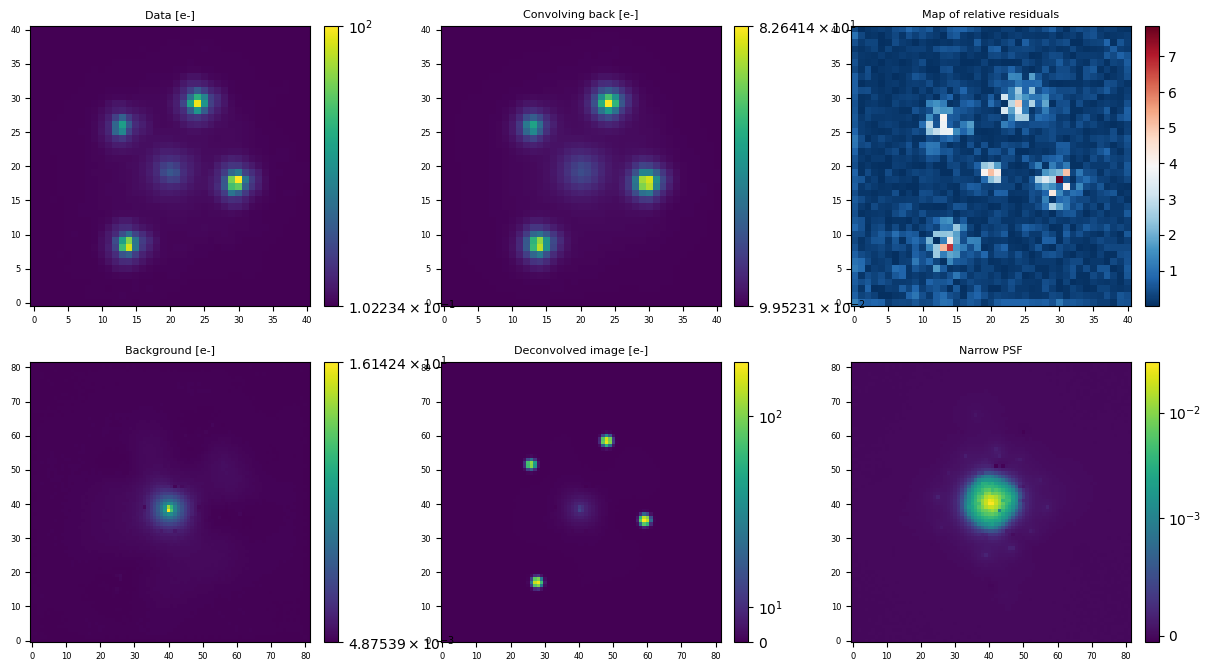

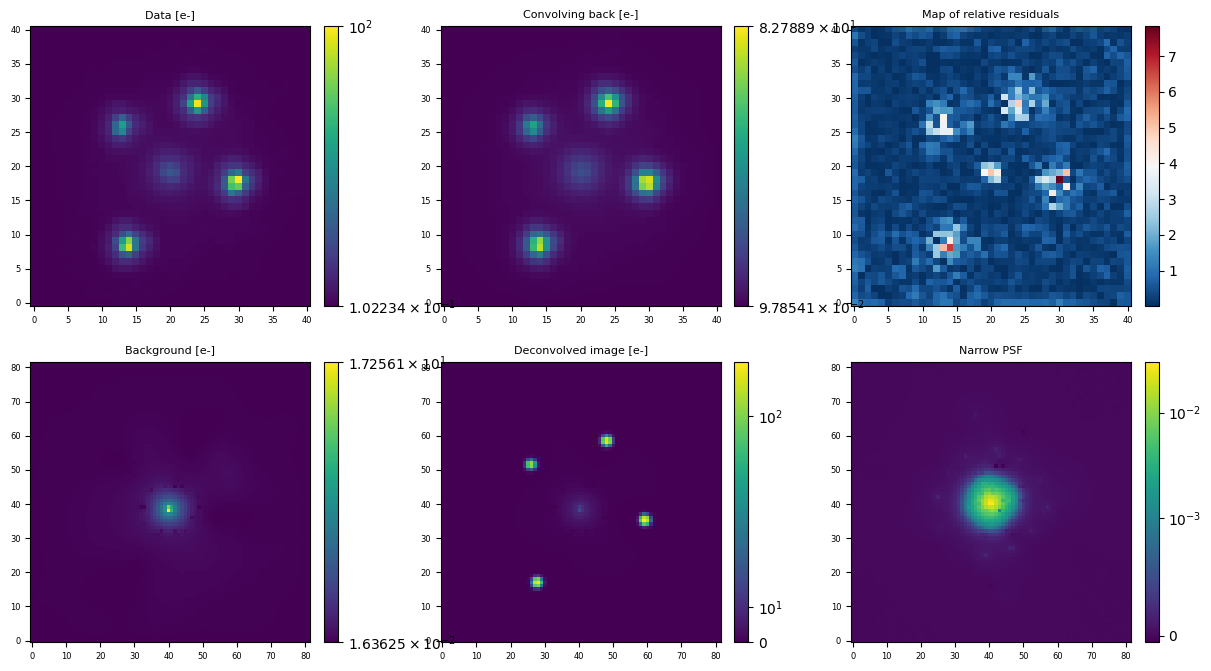

In [188]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [[], #step 1 : fix the Sersic profile and the astrometry, release the background
                    ['pts-source-astrometry']
                    #['background'],
        ]
    
optim_list = ['adabelief','adabelief']
kwargs_optax1 = {'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 5e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optax2 = {
        'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optim_list = [kwargs_optax1, kwargs_optax2] 
prior_list=[None,None]

parameters = ParametersDeconv(kwargs_partial, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters,  noisemaps**2, narrow_psfs, 2,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales=5,
                                                                                    #lambda_scales = 1, lambda_hf =1, 
                                                                                    lambda_positivity_ps=1000, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = True, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

Step 1, optimiser adabelief
Step 2, optimiser adabelief
{'kwargs_analytic': {'a': Array([10.671181 ,  9.6775465,  9.659099 ,  5.7797203], dtype=float32), 'c_x': Array([ 9.622521 ,  4.037377 , -6.1630273, -7.0771184], dtype=float32), 'c_y': Array([ -2.3807542,   9.215029 , -11.496096 ,   5.770941 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.0175503], dtype=float32), 'h': Array([-0.0006991 ,  0.00153294,  0.00210101, ...,  0.00642717,
        0.00198701, -0.00016608], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Overall Reduced Chi2 :  0.5508493


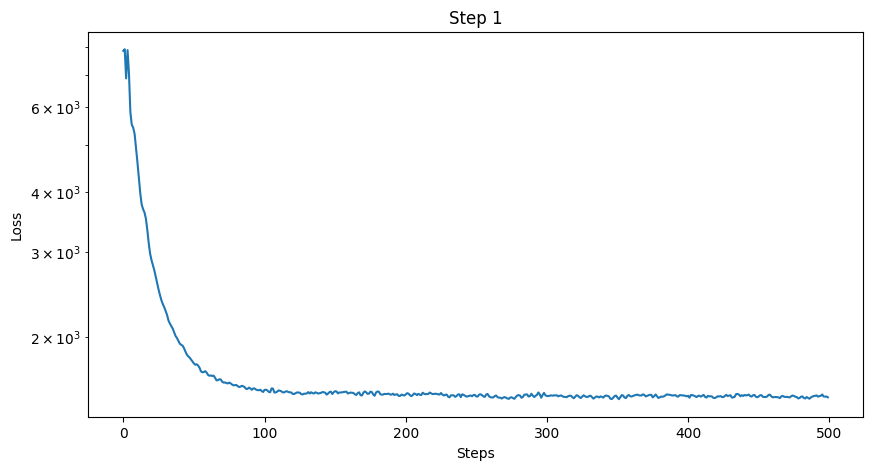

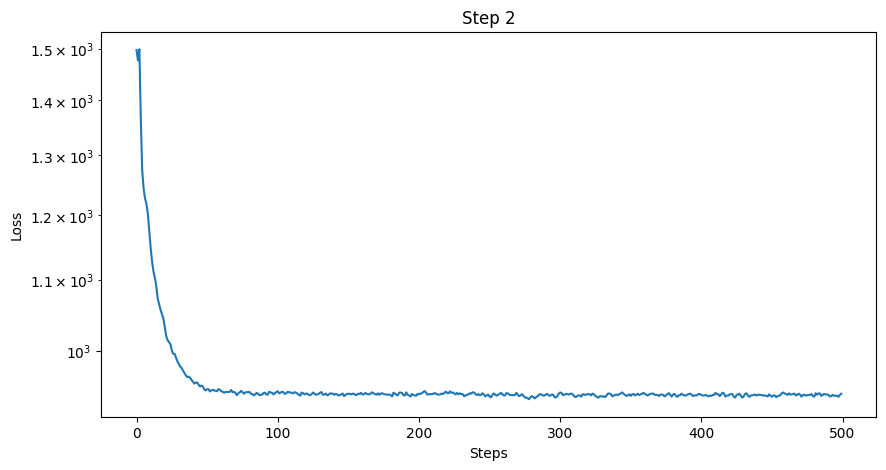

In [189]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

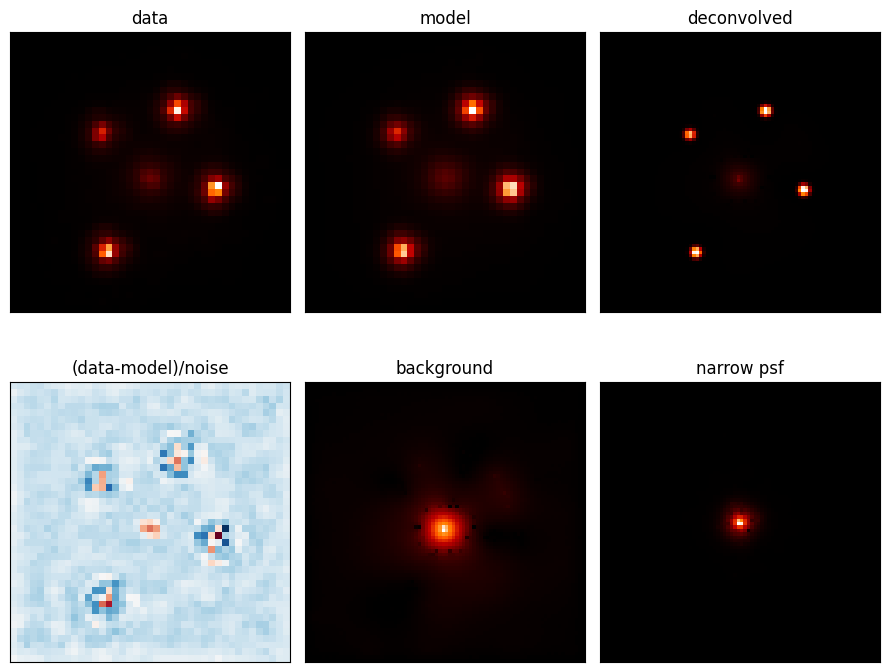

In [190]:
view_deconv_model(model, kwargs_final, data,  noisemaps**2)

In [206]:
model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(data, 
                                                                       sigma2, 
                                                                       narrow_psfs, 
                                                                       initial_c_x,
                                                                       initial_c_y,
                                                                       2,
                                                                       initial_a = brightnesses,
                                                                       N_sersic = 1)
#kwargs_init["kwargs_analytic"] = kwargs_final["kwargs_analytic"].copy()
#kwargs_init["kwargs_background"] = kwargs_final["kwargs_background"].copy()
kwargs_init['kwargs_sersic']['amp'][0] = 100
kwargs_init['kwargs_sersic']['e1'][0] = 0.0
kwargs_init['kwargs_sersic']['e2'][0] = 0.0
kwargs_init["kwargs_sersic"]["R_sersic"] = np.array([5.0])
kwargs_init['kwargs_sersic']['center_x'][0] = ptx_non_lens[0]
kwargs_init['kwargs_sersic']['center_y'][0] = pty_non_lens[0]
parameters = ParametersDeconv(kwargs_init, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)


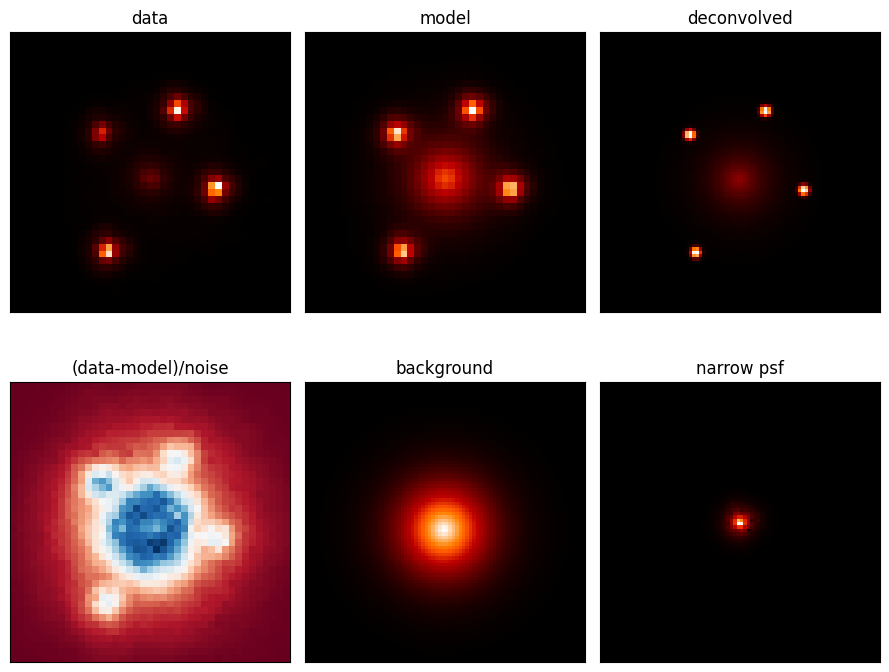

In [207]:
view_deconv_model(model, kwargs_init, data, sigma2)

Step 1, fixing : ['pts-source-astrometry', 'background']
Step 1/2 took  9 seconds
Kwargs partial at step 1/2 {'kwargs_analytic': {'a': Array([12.071758 , 10.739043 , 10.576181 ,  6.7711616], dtype=float32), 'c_x': Array([ 9.607436 ,  4.011773 , -6.2028117, -7.088105 ], dtype=float32), 'c_y': Array([ -2.3926053,   9.183629 , -11.535563 ,   5.731084 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}, 'kwargs_sersic': {'amp': Array([7.461967], dtype=float32), 'R_sersic': Array([0.], dtype=float32), 'n_sersic': Array([0.5], dtype=float32), 'center_x': Array([58.283783], dtype=float32), 'center_y': Array([53.725716], dtype=float32), 'e1': Array([0.], dtype=float32), 'e2': Array([0.], dtype=float32)}}
Loss :  7877.4067
Overall Reduced Chi2 :  9.372286
Step 2, fixing : ['background']
Step 2/2 took  6 secon

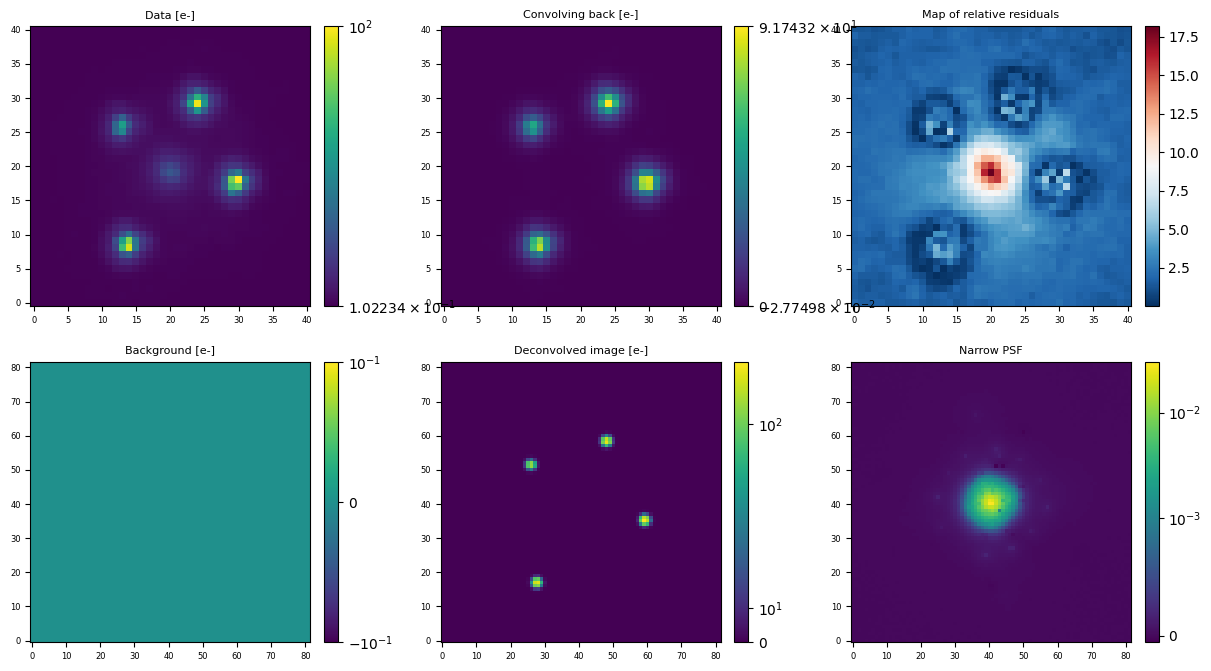

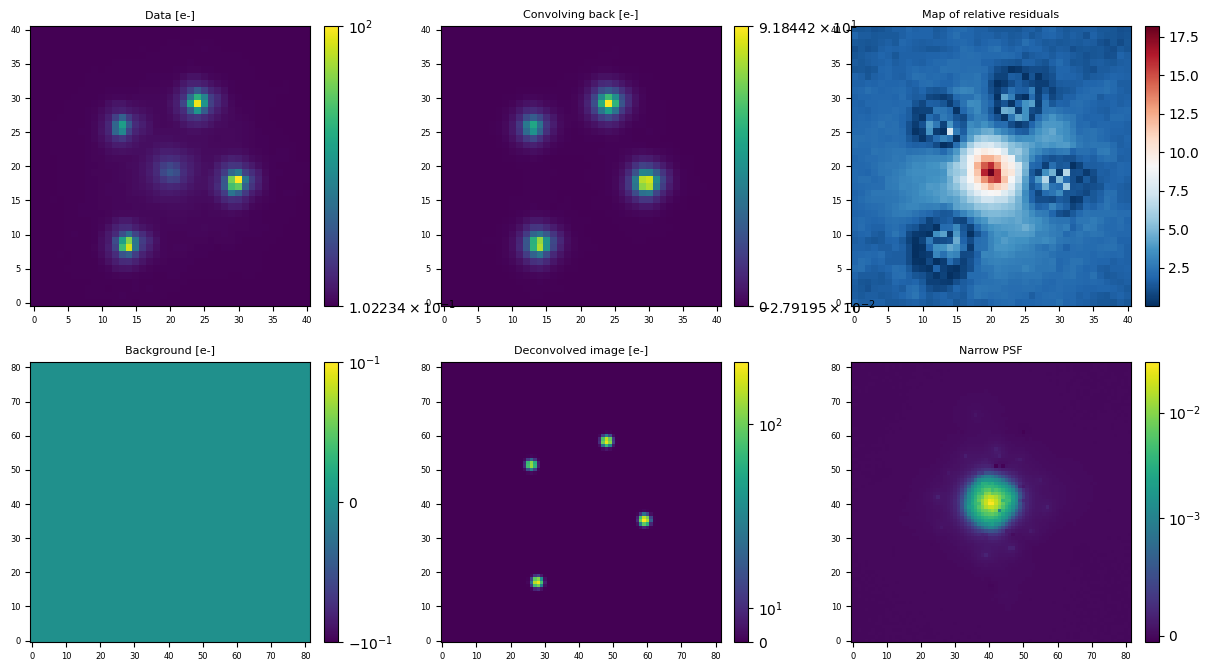

In [208]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['pts-source-astrometry', 'background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
                    ['background'], #step 2: release astrometry, keep the pixelated background constant.
        ]
    
#Since we have no regularisation, we can use 'l-bfgs-b'. 
optim_list = ['l-bfgs-b','l-bfgs-b']

#l-fgs-b, you can use the following parameters: 
kwargs_lbfgs = {'maxiter':50}

#list of configuration for the optimsers 
kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

#we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
prior_list=[None,None]

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, 2,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 0, lambda_hf =0, 
                                                                                    lambda_positivity_ps=100, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

Step 1, optimiser l-bfgs-b
Step 2, optimiser l-bfgs-b


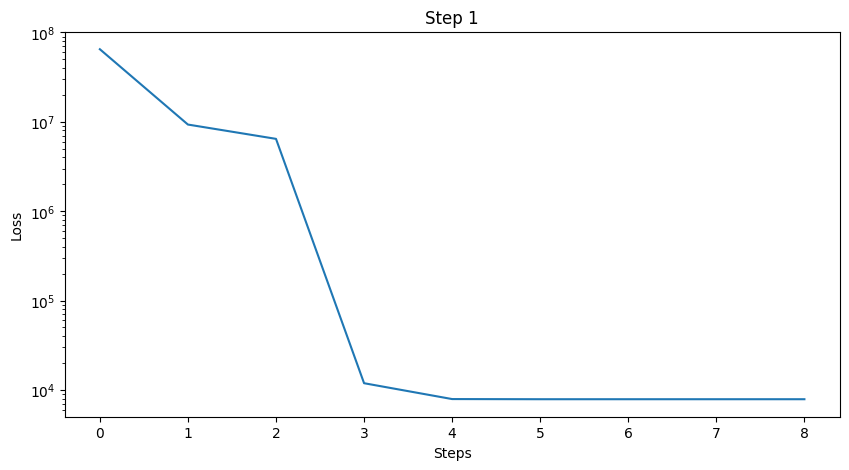

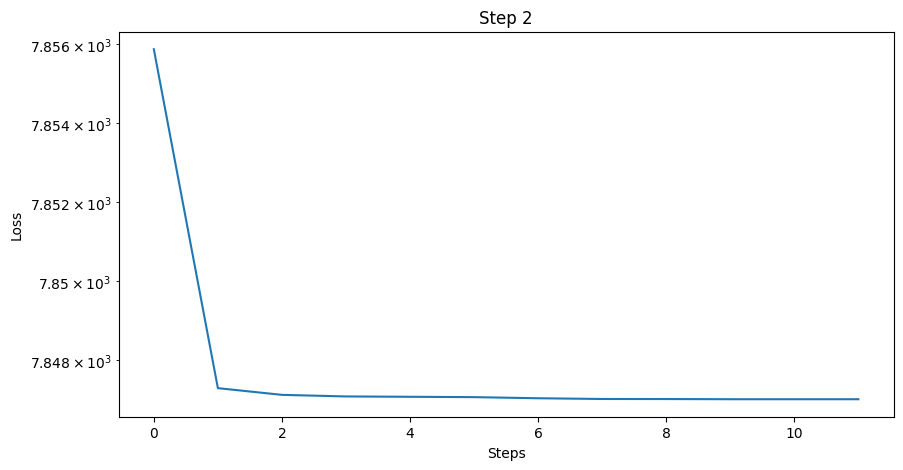

In [209]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

{'kwargs_analytic': {'a': Array([12.078168 , 10.740512 , 10.611852 ,  6.7826295], dtype=float32),
                     'alpha': Array([0.], dtype=float32),
                     'c_x': Array([ 9.577972 ,  4.0354686, -6.139379 , -7.035229 ], dtype=float32),
                     'c_y': Array([ -2.3799422,   9.174528 , -11.468936 ,   5.7160974], dtype=float32),
                     'dx': Array([0.], dtype=float32),
                     'dy': Array([0.], dtype=float32)},
 'kwargs_background': {'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
                       'mean': Array([0.], dtype=float32)},
 'kwargs_sersic': {'R_sersic': Array([0.], dtype=float32),
                   'amp': Array([7.461967], dtype=float32),
                   'center_x': Array([58.283783], dtype=float32),
                   'center_y': Array([53.725716], dtype=float32),
                   'e1': Array([0.], dtype=float32),
                   'e2': Array([0.], dtype=float32),
                   'n_sersic': 

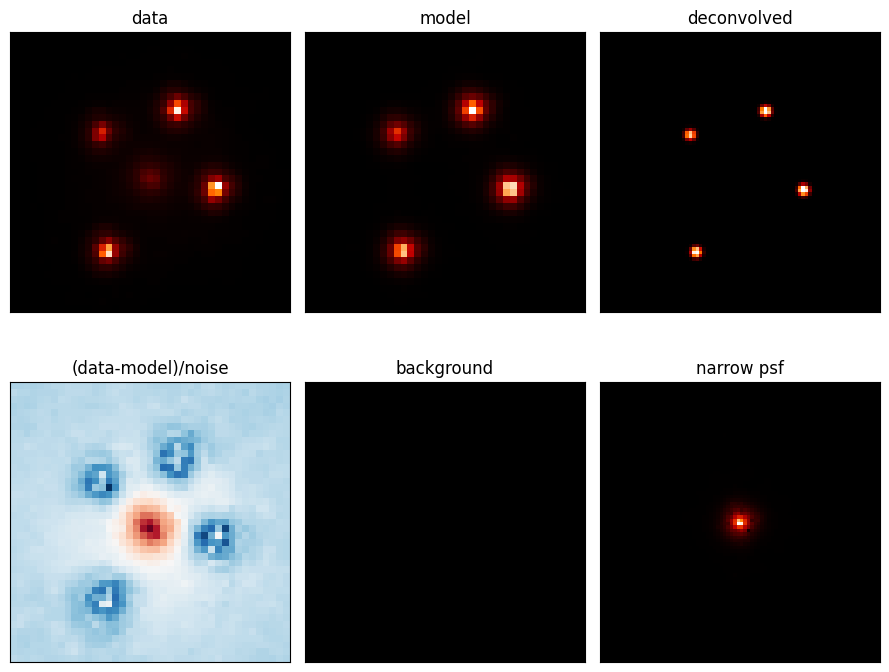

In [210]:
# Printing and visualizing the partial results
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
pprint(kwargs_partial)
view_deconv_model(model, kwargs_partial, data, sigma2)

Step 1, fixing : ['sersic', 'pts-source-astrometry']


optax.adabelief: 100%|██████████| 1000/1000 [00:04<00:00, 230.78it/s]


Step 1/3 took  5 seconds
Kwargs partial at step 1/3 {'kwargs_analytic': {'a': Array([10.158984 ,  9.16064  ,  9.17422  ,  5.4201765], dtype=float32), 'c_x': Array([ 9.577972 ,  4.0354686, -6.139379 , -7.035229 ], dtype=float32), 'c_y': Array([ -2.3799422,   9.174528 , -11.468936 ,   5.7160974], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0.07916798, 0.30676925, 0.15660173, ..., 0.14056885, 0.13551608,
       0.20508114], dtype=float32)}, 'kwargs_sersic': {'amp': Array([7.461967], dtype=float32), 'R_sersic': Array([0.], dtype=float32), 'n_sersic': Array([0.5], dtype=float32), 'center_x': Array([58.283783], dtype=float32), 'center_y': Array([53.725716], dtype=float32), 'e1': Array([0.], dtype=float32), 'e2': Array([0.], dtype=float32)}}
Loss :  602.00183
Overall Reduced Chi2 :  0.6248595
Step 2, fixing : ['sersic']


optax.adabelief: 100%|██████████| 5000/5000 [00:07<00:00, 693.89it/s] 


Step 2/3 took  9 seconds
Kwargs partial at step 2/3 {'kwargs_analytic': {'a': Array([9.143272 , 8.280326 , 7.6545324, 4.3502073], dtype=float32), 'c_x': Array([ 9.596702 ,  4.0347395, -6.191297 , -7.1047583], dtype=float32), 'c_y': Array([ -2.4206173,   9.241697 , -11.49657  ,   5.6980233], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([1.3516934 , 0.20242351, 0.05340384, ..., 0.13595821, 0.06276588,
       0.08858018], dtype=float32)}, 'kwargs_sersic': {'amp': Array([7.461967], dtype=float32), 'R_sersic': Array([0.], dtype=float32), 'n_sersic': Array([0.5], dtype=float32), 'center_x': Array([58.283783], dtype=float32), 'center_y': Array([53.725716], dtype=float32), 'e1': Array([0.], dtype=float32), 'e2': Array([0.], dtype=float32)}}
Loss :  365.76813
Overall Reduced Chi2 :  0.36270463
Step 3, fixing : []


optax.adabelief: 100%|██████████| 5000/5000 [00:10<00:00, 466.40it/s] 


Step 3/3 took 13 seconds
Kwargs partial at step 3/3 {'kwargs_analytic': {'a': Array([9.032851, 8.113095, 7.247281, 4.229012], dtype=float32), 'c_x': Array([ 9.602171 ,  4.0355597, -6.2086673, -7.1094475], dtype=float32), 'c_y': Array([ -2.4137619,   9.252455 , -11.493858 ,   5.6875772], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([1.2884222 , 0.18119912, 0.05977536, ..., 0.02501709, 0.02164216,
       0.0266039 ], dtype=float32)}, 'kwargs_sersic': {'amp': Array([7.461967], dtype=float32), 'R_sersic': Array([0.], dtype=float32), 'n_sersic': Array([0.5], dtype=float32), 'center_x': Array([58.283783], dtype=float32), 'center_y': Array([53.725716], dtype=float32), 'e1': Array([0.], dtype=float32), 'e2': Array([0.], dtype=float32)}}
Loss :  366.11557
Overall Reduced Chi2 :  0.35847592


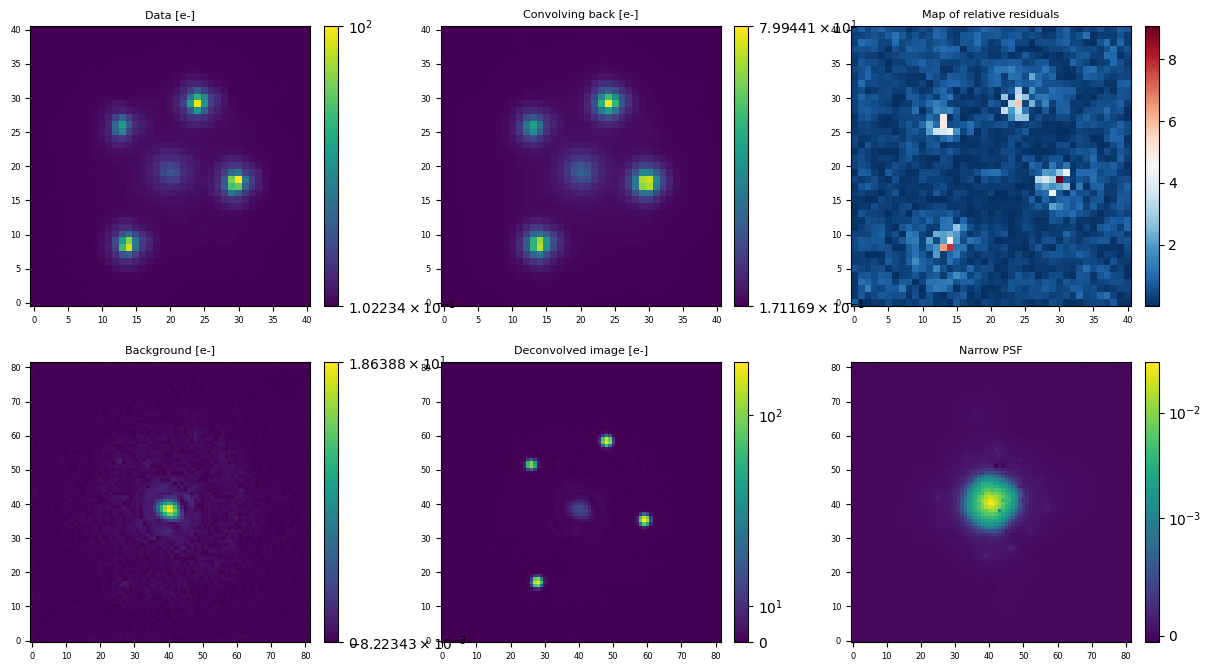

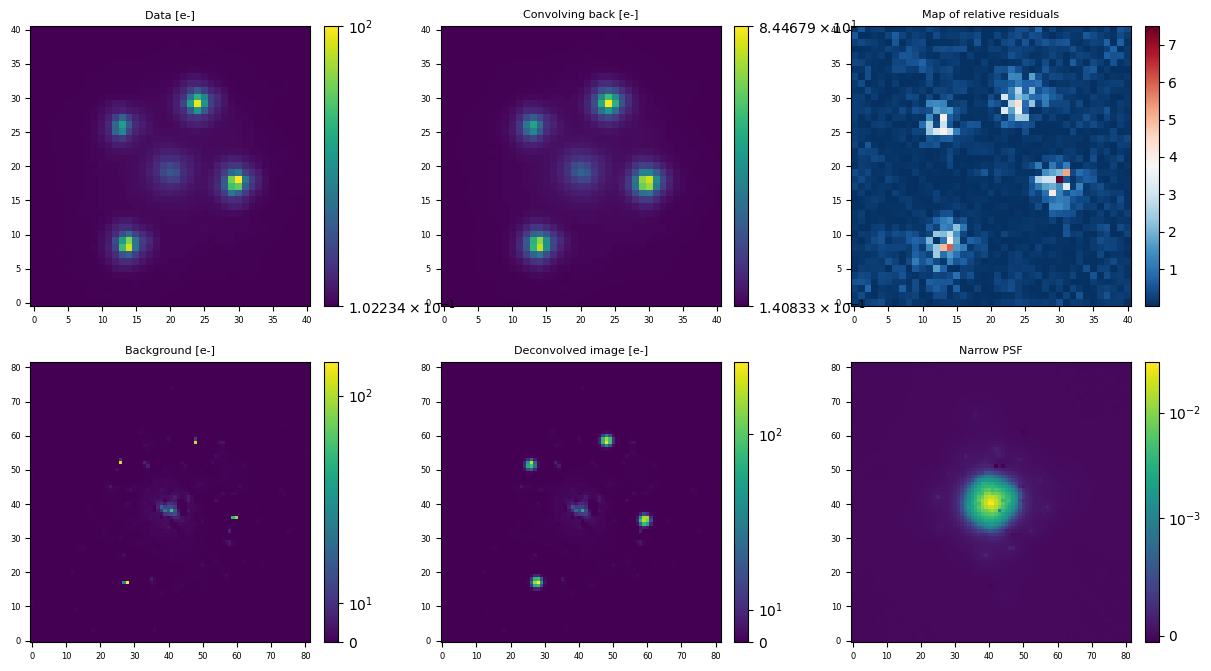

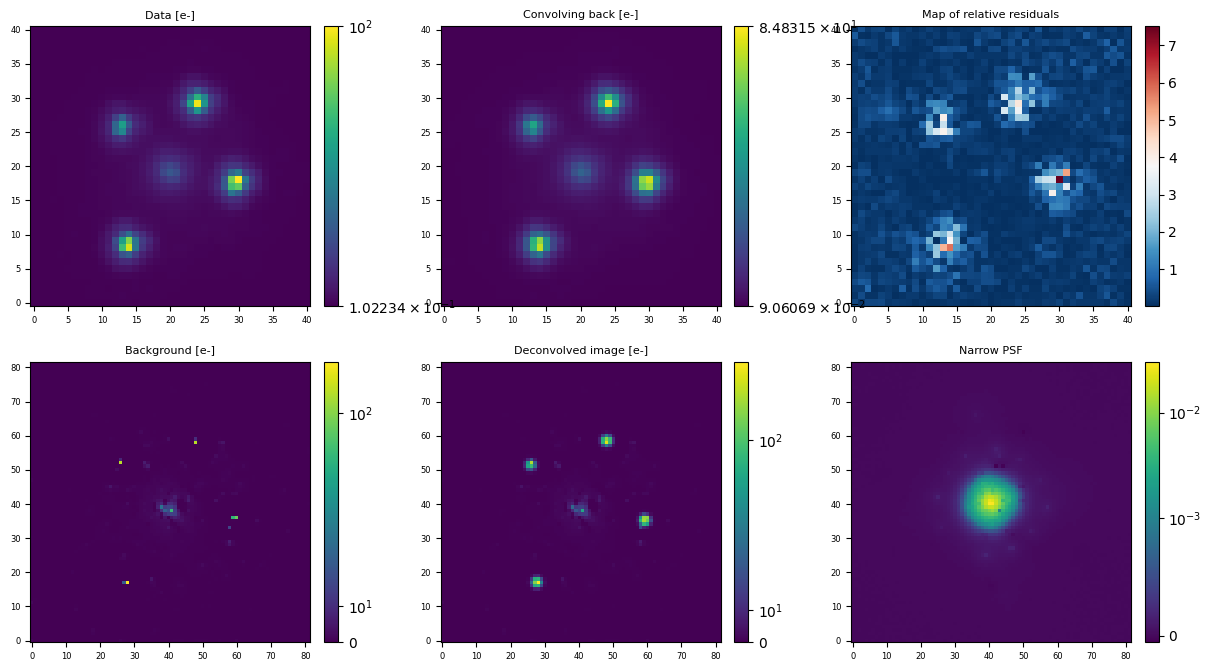

In [211]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['sersic', 'pts-source-astrometry'], #step 1 : fix the Sersic profile and the astrometry, release the background
                    ['sersic'],
                    []
        ]
    
optim_list = ['adabelief','adabelief',"adabelief"]
kwargs_optax1 = {'max_iterations': 1_000, 'min_iterations': None,
        'init_learning_rate': 5e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optax2 = {
        'max_iterations': 5_000, 'min_iterations': None,
        'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optax3 = {
        'max_iterations': 5_000, 'min_iterations': None,
        'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optim_list = [kwargs_optax1, kwargs_optax2,kwargs_optax3] 
prior_list=[None,None,None]

parameters = ParametersDeconv(kwargs_partial, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma2, narrow_psfs, 2,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 1, lambda_hf =1, 
                                                                                    lambda_positivity_ps=100, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

Step 1, optimiser adabelief
Step 2, optimiser adabelief
Step 3, optimiser adabelief
{'kwargs_analytic': {'a': Array([10.649999,  9.688762,  9.660172,  5.777273], dtype=float32), 'c_x': Array([ 9.62454  ,  4.0297647, -6.171048 , -7.0797   ], dtype=float32), 'c_y': Array([ -2.3731732,   9.221006 , -11.495344 ,   5.7815614], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0.05347797, 0.09314933, 0.10460787, ..., 0.02214212, 0.01360109,
       0.00528333], dtype=float32)}, 'kwargs_sersic': {'amp': Array([7.0700607], dtype=float32), 'R_sersic': Array([0.], dtype=float32), 'n_sersic': Array([0.5], dtype=float32), 'center_x': Array([54.399673], dtype=float32), 'center_y': Array([50.266968], dtype=float32), 'e1': Array([0.], dtype=float32), 'e2': Array([0.], dtype=float32)}}
Overall Reduced Chi2 :  0.4271853


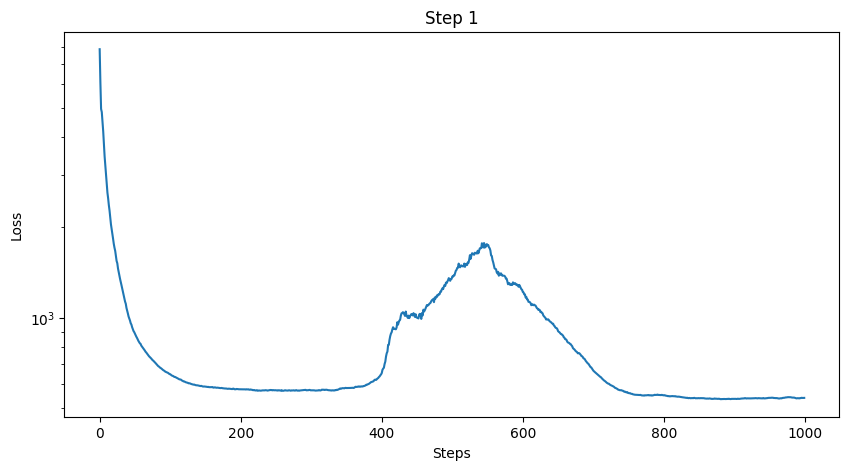

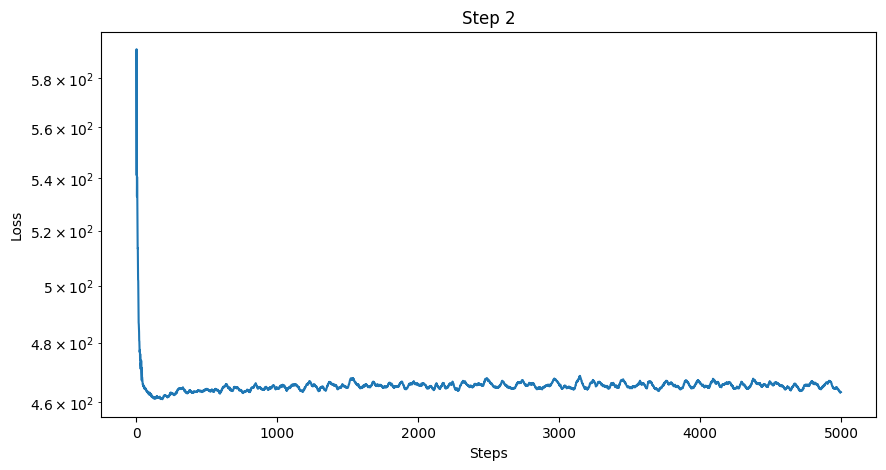

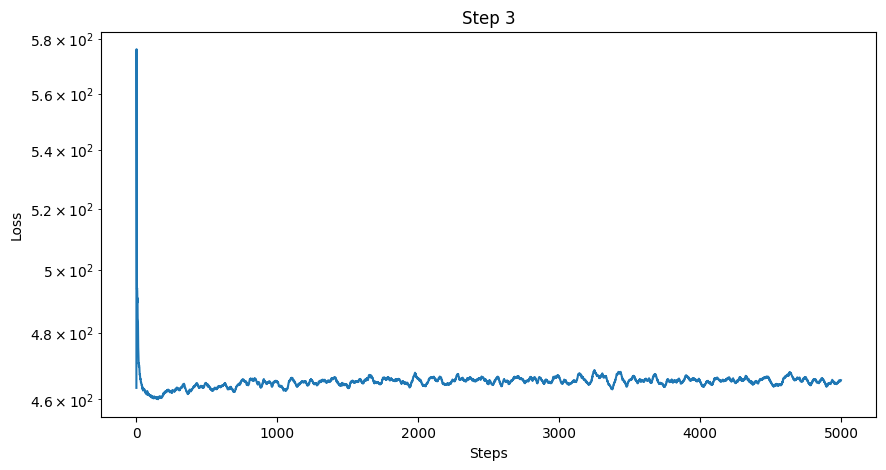

In [202]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

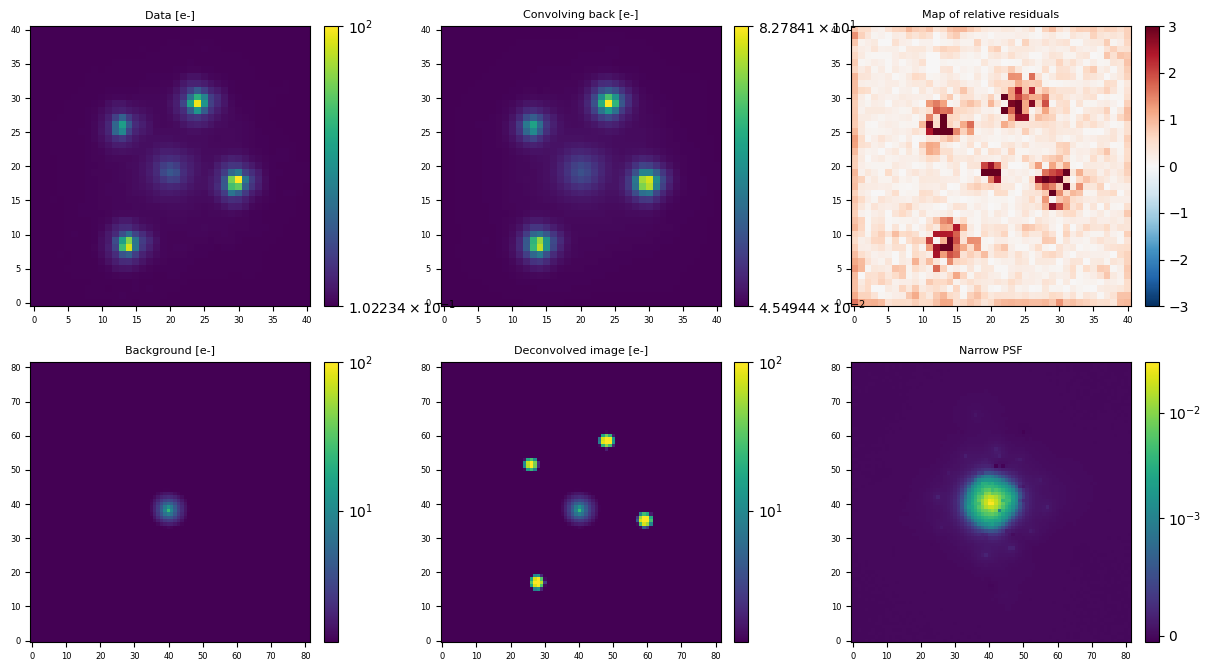

In [198]:
# Retrieving different elements of the deconvolved image
epoch = 0
output = model.model(kwargs_final)[epoch] 
deconv, h = model.getDeconvolved(kwargs_final, epoch)

cut_dict = {
            'linthresh':[100,100,None,10,10,1e-3],
            'vmin':[None,None, -3, 2, 2, None],
            'vmax':[None, None, 3, 100,100, None],
        }
#cut of the panels, given from left to right and from top to bottom
fig2 = plot_deconvolution(model, data, sigma2, narrow_psfs, kwargs_final, epoch = epoch, units='e-', cut_dict = cut_dict)
